In [ ]:
# Import Library
import pandas as pd
import numpy as np
import re
import string
import nltk
import seaborn as sns
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE

In [ ]:
# Membaca dan Melihat Data
data = pd.read_csv('/content/skripsi_topik.csv')
data.head()


,judul,abstrak,kategori
0,Klasterisasi Lokasi Tingkat Penyebaran Covid-1...,Disease is a bad condition in certain organs o...,Data Engineering
1,Sistem Pakar Diagnosa Kerusakan Smartphone Men...,Smartphone is one of the devices of the develo...,Business Intelligence
2,Sistem Pendukung Keputusan Penentuan Kelayakan...,The existence of a school library is important...,Business Intelligence
3,Analisa Perbandingan Performa Algoritma Convol...,This study compares the background clutter and...,Information Retrieval
4,Sistem Peramalan Harga Jual Ternak Menggunakan...,Value forecasting helps to plan for the future...,Business Intelligence


In [ ]:
# Hapus Data Duplicate

data = data.drop_duplicates(subset=['judul'])

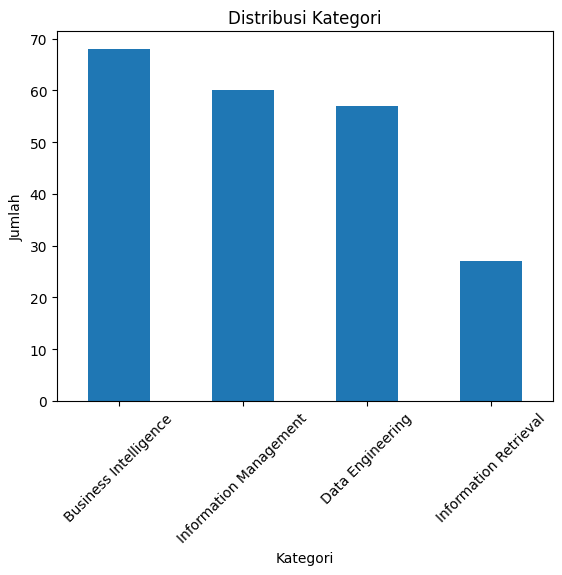

In [ ]:
# Cek Distribusi Kelas
data['kategori'].value_counts().plot(kind='bar', title='Distribusi Kategori')
plt.xlabel('Kategori')
plt.ylabel('Jumlah')
plt.xticks(rotation=45)
plt.show()

In [ ]:
def preprocess_text(text):
    import re
    import string
    from nltk.corpus import stopwords
    from nltk.stem import WordNetLemmatizer

    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()

    original_text = text
    # Lowercase
    lower_text = text.lower()
    # Remove Number
    no_numbers = re.sub(r'\d+', '', lower_text)
    # Remove Punctuation
    no_punct = no_numbers.translate(str.maketrans('', '', string.punctuation))
    # Remove Stopwords
    tokens_before_stopwords = no_punct.split() # Split into words first
    tokens_no_stopwords = [t for t in tokens_before_stopwords if t not in stop_words]
    # Lemmatization
    tokens_lemmatized = [lemmatizer.lemmatize(t) for t in tokens_no_stopwords]
    # Tokenization
    tokens = tokens_lemmatized
    # Final Cleaned Text
    cleaned_text = ' '.join(tokens_lemmatized)

    return {
        'Original Text': original_text,
        'Lowercase': lower_text,
        'No Numbers and Punctuation': no_punct,
        'Tokens': tokens,
        'No Stopwords': tokens_no_stopwords,
        'Lemmatized': tokens_lemmatized,
        'Cleaned Text': cleaned_text
    }


In [ ]:
# Menampilkan data yg telah di preprocesssing
import nltk
nltk.download('stopwords')
nltk.download('wordnet')

first_row = data.iloc[0]
hasil = preprocess_text(first_row['abstrak'])

judul_df = pd.DataFrame({
    'Result': [first_row['judul']]
}, index=['Judul'])

kategori_df = pd.DataFrame({
    'Result': [first_row['kategori']]
}, index=['Kategori'])

hasil_df = pd.DataFrame.from_dict(hasil, orient='index', columns=['Result'])
final_df = pd.concat([judul_df, hasil_df, kategori_df])

display(final_df)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,Result
Judul,Klasterisasi Lokasi Tingkat Penyebaran Covid-1...
Original Text,Disease is a bad condition in certain organs o...
Lowercase,disease is a bad condition in certain organs o...
No Numbers and Punctuation,disease is a bad condition in certain organs o...
Tokens,"[disease, bad, condition, certain, organ, body..."
No Stopwords,"[disease, bad, condition, certain, organs, bod..."
Lemmatized,"[disease, bad, condition, certain, organ, body..."
Cleaned Text,disease bad condition certain organ body part ...
Kategori,Data Engineering


In [ ]:
data['cleaned'] = data['abstrak'].apply(lambda x: preprocess_text(x)['Cleaned Text'])

In [ ]:
# Label Encoder Kategori
from sklearn.preprocessing import LabelEncoder

# Inisialisasi Encoder
label_encoder = LabelEncoder()

# Ubah Kategori Menjadi Numerik
data['label'] = label_encoder.fit_transform(data['kategori'])

In [ ]:
# Distribusi Kelas
print("\nJumlah data per kelas:")
print(data['label'].value_counts())

print("\nDistribusi kelas:")
mapping = dict(zip(label_encoder.transform(label_encoder.classes_), label_encoder.classes_))
print("Mapping Angka ke Nama Kelas:", mapping)


Jumlah data per kelas:
label
0    68
2    60
1    57
3    27
Name: count, dtype: int64

Distribusi kelas:
Mapping Angka ke Nama Kelas: {np.int64(0): 'Business Intelligence', np.int64(1): 'Data Engineering', np.int64(2): 'Information Management', np.int64(3): 'Information Retrieval'}


In [ ]:
# Tf-idf
tfidf = TfidfVectorizer(ngram_range=(1, 2), max_df=0.8, min_df=2, sublinear_tf=True)
X = tfidf.fit_transform(data['cleaned'])
y = data['label']

In [ ]:
# Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [ ]:
# SMOTE (Imbalanced Class)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train.toarray(), y_train)

In [ ]:
# Latih Model
model = MultinomialNB()
model.fit(X_train_smote, y_train_smote)

MultinomialNB()

                        precision    recall  f1-score   support

 Business Intelligence       0.81      0.81      0.81        21
      Data Engineering       0.86      0.71      0.77        17
Information Management       0.73      0.89      0.80        18
 Information Retrieval       0.86      0.75      0.80         8

              accuracy                           0.80        64
             macro avg       0.81      0.79      0.80        64
          weighted avg       0.80      0.80      0.80        64



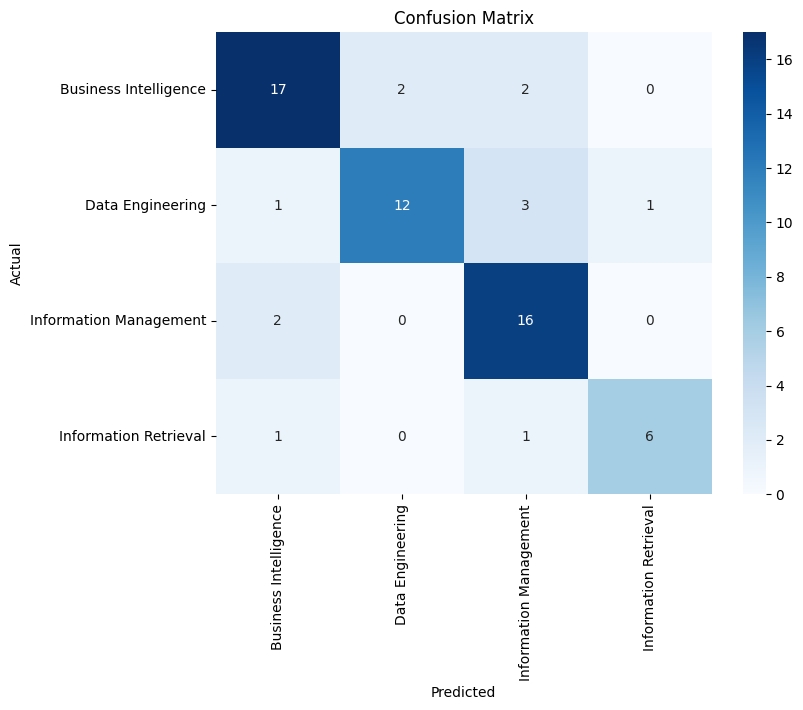

In [ ]:
# Evaluasi
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True,
            fmt='d',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Evaluasi Matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')  # macro = rata-rata antar kelas
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

print("Evaluation Metrics")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Evaluation Metrics
Accuracy : 0.7969
Precision: 0.8128
Recall   : 0.7886
F1 Score : 0.7959


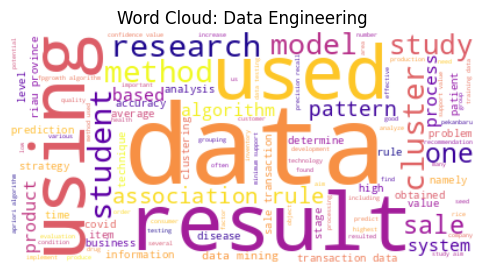

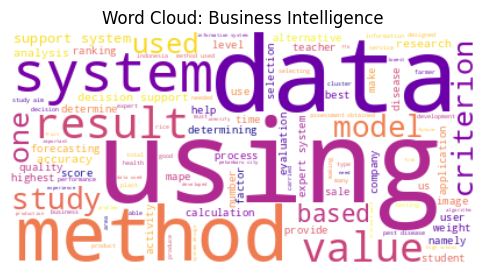

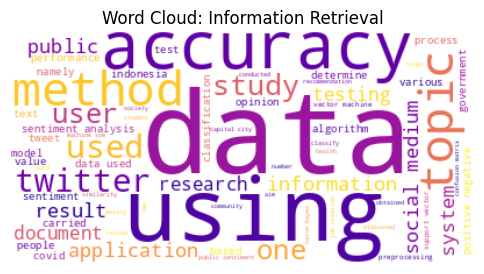

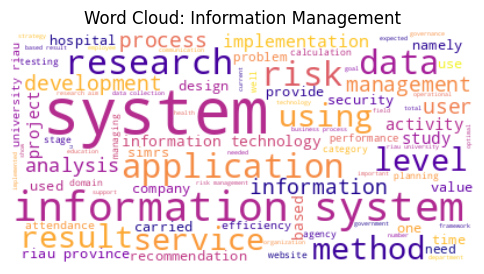

In [ ]:
# Apply preprocessing and create 'cleaned' and 'tokens_list' columns
data['processed'] = data['abstrak'].apply(preprocess_text)
data['cleaned'] = data['processed'].apply(lambda x: x['Cleaned Text'])
data['tokens_list'] = data['processed'].apply(lambda x: x['Tokens'])

data = data.drop(columns=['processed'])
from wordcloud import WordCloud
import matplotlib.pyplot as plt

for label in data['label'].unique():
    all_tokens = data[data['label'] == label]['tokens_list'].sum()
    text = ' '.join(all_tokens)

    # Tampilkan WordCloud
    plt.figure(figsize=(6, 4))
    plt.imshow(
        WordCloud(background_color='white', colormap='plasma').generate(text),
        interpolation='bilinear'
    )
    plt.title(f"Word Cloud: {label_encoder.inverse_transform([label])[0]}")
    plt.axis('off')
    plt.show()


In [ ]:
def prediksi_dan_rekomendasi_dengan_df(abstrak_baru, model, tfidf, data, top_n=3):
    import numpy as np
    import pandas as pd
    from sklearn.metrics.pairwise import cosine_similarity

    # Preprocessing
    hasil = preprocess_text(abstrak_baru)
    cleaned_text = hasil['Cleaned Text']

    # TF-IDF transform
    X_new = tfidf.transform([cleaned_text])

    # Prediksi kategori
    y_pred_numeric = model.predict(X_new)
    predicted_category = y_pred_numeric[0]

    # Filter data berdasarkan kategori
    df_kategori = data[data['label'] == predicted_category]
    if df_kategori.empty:
        print("Tidak ditemukan data pada kategori ini.")
        return None

    # Cosine similarity
    X_kategori = tfidf.transform(df_kategori['cleaned'])
    similarities = cosine_similarity(X_new, X_kategori).flatten()

    # Ambil top-n similarity tertinggi
    top_indices = np.argsort(similarities)[-top_n:][::-1]
    top_scores = similarities[top_indices]

    # Data dokumen mirip
    dok_mirip = df_kategori.iloc[top_indices].copy()
    dok_mirip['Similarity Score'] = top_scores

    # Tambahkan hasil similarity ke output utama
    hasil_df = pd.DataFrame({
        'Original Text': [abstrak_baru],
        'Lowercase': [hasil['Lowercase']],
        'No Numbers and Punctuation': [hasil['No Numbers and Punctuation']],
        'Tokens': [hasil['Tokens']],
        'No Stopwords': [hasil['No Stopwords']],
        'Lemmatized': [hasil['Lemmatized']],
        'Cleaned Text': [cleaned_text],
        'Kategori': [predicted_category],
    })

    for i in range(top_n):
        hasil_df[f'Similarity Score Doc {i+1}'] = [top_scores[i]]

    return hasil_df, dok_mirip[['judul', 'abstrak', 'Similarity Score']]

In [ ]:
# Input abstrak baru
abstrak_baru = """
Procurement of assets by auction requires a decision support in selecting the winning bidder so that decision makers can pick and choose
the winner of the auction. This study aims to develop a Decision Support System (DSS), which serves as an aid in decision making in the
process of evaluating the winning bidder acquisitions. In order to achieve the purpose of SPK well then helped by using one of the
methods in decision-making that is the method of Simple Additive weighting method (SAW) to evaluate alternatives in the provision of
asset based decision-making criteria. This method has the advantage criteria (benefits) and cost criteria (cost). Criteria advantage
(benefit) is used when considering the aspects of decision making maximum profit. While the cost criteria (cost) is the inverse of the
attributes of an advantage, in this draft decision will be looking for a minimal fee. The results may support the decision on the selection
of an alternative evaluation of acquisitions winners based on predetermined criteria.
"""

# Jalankan fungsi
hasil_df, rekomendasi_df = prediksi_dan_rekomendasi_dengan_df(abstrak_baru, model, tfidf, data)

# Tampilkan hasil
display(hasil_df)
display(rekomendasi_df)

,Original Text,Lowercase,No Numbers and Punctuation,Tokens,No Stopwords,Lemmatized,Cleaned Text,Kategori,Similarity Score Doc 1,Similarity Score Doc 2,Similarity Score Doc 3
0,\nProcurement of assets by auction requires a ...,\nprocurement of assets by auction requires a ...,\nprocurement of assets by auction requires a ...,"[procurement, asset, auction, requires, decisi...","[procurement, assets, auction, requires, decis...","[procurement, asset, auction, requires, decisi...",procurement asset auction requires decision su...,0,0.216412,0.205094,0.195999


,judul,abstrak,Similarity Score
68,Sistem Pendukung Keputusan Pemilihan Supplier ...,viii The decision support system aims to prov...,0.216412
223,Sistem Pendukung Keputusan Perekrutan Karyawan...,In an effort to improve the efficiency and eff...,0.205094
85,Sistem Pendukung Keputusan Pemilihan Guru Berp...,This Decision Support System for the Selection...,0.195999


In [ ]:
# Input abstrak baru
abstrak_baru = """
Data Mining is a series of processes to extract additional value in the form of information that has been known manually
from a database by extracting patterns from data with the aim of manipulating data into more valuable information obtained by
extracting and extracting patterns important or pull the data contained in the database. Data Mining technique has various kinds of
algorithms and techniques for solving problems related to data, one of which is the FP-Growth algorithm and the association rule
technique. The information displayed using the association rule technique, which displays the value of support and confidence from
each data mining process. With the FP-Growth algorithm, it is proven from the results of the tests carried out, the FP-Growth
algorithm and the association rule technique run as expected and can be implemented in this Data Mining.
"""
# Jalankan fungsi
hasil_df, rekomendasi_df = prediksi_dan_rekomendasi_dengan_df(abstrak_baru, model, tfidf, data)

# Tampilkan hasil
display(hasil_df)
display(rekomendasi_df)

,Original Text,Lowercase,No Numbers and Punctuation,Tokens,No Stopwords,Lemmatized,Cleaned Text,Kategori,Similarity Score Doc 1,Similarity Score Doc 2,Similarity Score Doc 3
0,\nData Mining is a series of processes to extr...,\ndata mining is a series of processes to extr...,\ndata mining is a series of processes to extr...,"[data, mining, series, process, extract, addit...","[data, mining, series, processes, extract, add...","[data, mining, series, process, extract, addit...",data mining series process extract additional ...,1,0.335816,0.322031,0.289399


,judul,abstrak,Similarity Score
139,Analisis Pola Pembelian Produk Toserba Menggun...,Advances in technology make business people t...,0.335816
11,Market Basket Analysis Dengan Algoritma Fp-Gro...,Market Basket Analysis (MBA) is a method of fi...,0.322031
186,Penerapan Algoritma Fp-Growth Untuk Menganalis...,Pagaruyung Diesel store in Duri City has exper...,0.289399


In [ ]:
# Input abstrak baru
abstrak_baru = """
There are many organization which develop their information technology only based on the recommendation of certain vendors and
colleagues. The development of Information and Technology Systems need a proper consideration in order to avoid the chance of bigger
loss in the financial and investation sectors. The unsystematic development of Information and Technology Systems will not fulfil a long
term needs, there is no priority scale on it and it is not in line with the bussiness organization rhyme. The Strategic Planning Information
System is a systematic approach about what is considered to be the most effective and effecient to fulfil the needs of information. The
Strategic Planning Information System stated by Ward and Peppard (2002), which becomes the basis of this research, uses some analysis
methods, likeValue Chain and Critical Success Factors. The result of this research is a blue print of the strategic planning which is based
on the bussiness organization planning with the data gathered through the analysis method used and it involves all the organization
component.
"""

# Jalankan fungsi
hasil_df, rekomendasi_df = prediksi_dan_rekomendasi_dengan_df(abstrak_baru, model, tfidf, data)

# Tampilkan hasil
display(hasil_df)
display(rekomendasi_df)

,Original Text,Lowercase,No Numbers and Punctuation,Tokens,No Stopwords,Lemmatized,Cleaned Text,Kategori,Similarity Score Doc 1,Similarity Score Doc 2,Similarity Score Doc 3
0,\nThere are many organization which develop th...,\nthere are many organization which develop th...,\nthere are many organization which develop th...,"[many, organization, develop, information, tec...","[many, organization, develop, information, tec...","[many, organization, develop, information, tec...",many organization develop information technolo...,2,0.264262,0.228454,0.209135


,judul,abstrak,Similarity Score
72,Perencanaan Strategis Pengembangan Sistem Info...,Information system strategic planning is need...,0.264262
134,Perencanaan Strategis Sistem Informasi Dengan ...,Information system is a field of technology t...,0.228454
289,Perencanaan Strategis Sistem Informasi Menggun...,BAPPEDALITBANG Riau Province is a government o...,0.209135


In [ ]:
# Input abstrak baru
abstrak_baru = """
Scientific journals are periodical publications that contain scientific papers with data and information
written in accordance with the rules of scientific writing. Scientific journals used widely as a reference
to make a new research or continue the previous research. As the usage is growing, scientific journals
also easier to find digitally and available in a digital library such as Science Direct and IEEE, but the
searching process is still limited to Monolingual Information Retrieval, in which the search results
have the same language as the query inputted, even though the relevant documents also available in
other languages. This research is done to observe the result of implementing Cross Language
Information Retrieval that can do the searching process in one language for the input and retrieved
document in two languages. The final result is 8 out of 10 queries have a higher precision up to 74,5%
and recall up to 41,5%. Generally, system can retrieved the relevant documents in average for 84%.
"""
# Jalankan fungsi
hasil_df, rekomendasi_df = prediksi_dan_rekomendasi_dengan_df(abstrak_baru, model, tfidf, data)

# Tampilkan hasil
display(hasil_df)
display(rekomendasi_df)

,Original Text,Lowercase,No Numbers and Punctuation,Tokens,No Stopwords,Lemmatized,Cleaned Text,Kategori,Similarity Score Doc 1,Similarity Score Doc 2,Similarity Score Doc 3
0,\nScientific journals are periodical publicati...,\nscientific journals are periodical publicati...,\nscientific journals are periodical publicati...,"[scientific, journal, periodical, publication,...","[scientific, journals, periodical, publication...","[scientific, journal, periodical, publication,...",scientific journal periodical publication cont...,3,0.157433,0.114797,0.085593


,judul,abstrak,Similarity Score
7,Sistem Pencarian Judul Skripsi Menggunakan Met...,"Every year, student thesis research is increas...",0.157433
112,Analisis Penerimaan Penggunaan Website Digital...,The Riau University digital library is one of ...,0.114797
184,Stemming Bahasa Melayu Ocu Kampar Menggunakan ...,The Ocu language is among the dialects utilize...,0.085593


In [ ]:
# Simpan hasil ke file CSV
hasil_df.to_csv('hasil_prediksi.csv', index=False)
rekomendasi_df.to_csv('hasil_rekomendasi.csv', index=False)

print("Hasil prediksi dan rekomendasi telah disimpan ke 'hasil_prediksi.csv' dan 'hasil_rekomendasi.csv'")

Hasil prediksi dan rekomendasi telah disimpan ke 'hasil_prediksi.csv' dan 'hasil_rekomendasi.csv'
